# Case Study 1: Shelf-Life Prediction with a Keras MLP
Use `pandas` for food physicochemical data, `numpy` for arrays and standardisation, and `tensorflow.keras` for model development.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-6/notebooks/01_tabular_mlp_shelf_life_tensorflow_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



In [1]:
from pathlib import Path
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'tabular_shelf_life.csv'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-6/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

def make_split(n, test_fraction=0.2):
    idx = np.arange(n)
    np.random.shuffle(idx)
    cut = int(n * (1 - test_fraction))
    return idx[:cut], idx[cut:]

def standardize(train, test, axis=0):
    mean = train.mean(axis=axis, keepdims=True)
    std = train.std(axis=axis, keepdims=True) + 1e-8
    return (train - mean) / std, (test - mean) / std, mean, std

def history_table(history):
    hist = pd.DataFrame(history.history)
    return hist.tail(5).round(4)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (8, 4.8),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10
})

def plot_history(history, metrics=None, title='Training history'):
    hist = pd.DataFrame(history.history)
    metrics = metrics or [c for c in hist.columns if not c.startswith('val_')]
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.plot(hist.index + 1, hist[metric], label=f'train {metric}', linewidth=2)
        val_metric = f'val_{metric}'
        if val_metric in hist:
            ax.plot(hist.index + 1, hist[val_metric], label=f'validation {metric}', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()
    fig.suptitle(title, y=1.03, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_binary_confusion(y_true, y_pred, labels, title='Confusion matrix'):
    cm = confusion_matrix(y_true.astype(int), y_pred.astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


NumPy: 2.5.0
Pandas: 3.0.3
TensorFlow: 2.21.0
Keras: 3.15.0


In [2]:
df = pd.read_csv(DATA_DIR / 'tabular_shelf_life.csv')
print(df.shape)
display(df.head())
display(df.select_dtypes(include='number').describe().round(2))


(720, 9)


,food_type,moisture,pH,brix,protein,storage_temp,water_activity,packaging_o2,shelf_life_days
0,rice,84.947531,4.567878,10.722370,8.094076,15.599642,0.878051,11.478728,16.993027
1,cheese,75.820516,5.003071,9.318445,5.717268,0.965945,0.927250,7.128953,35.617337
2,cheese,54.071694,4.948902,16.591695,6.707214,8.610040,0.990000,4.833928,42.074301
3,yogurt,80.388297,5.242391,1.000000,9.473565,6.813645,0.951694,1.951006,19.010260
4,yogurt,78.528074,3.378243,11.534571,7.771585,0.000000,0.875329,11.506182,10.056128


,moisture,pH,brix,protein,storage_temp,water_activity,packaging_o2,shelf_life_days
count,720.00,720.00,720.00,720.00,720.00,720.00,720.00,720.00
mean,68.44,4.83,10.76,5.95,8.16,0.91,6.27,26.28
std,13.19,0.75,4.34,4.50,5.18,0.06,2.93,10.09
min,25.00,3.00,1.00,0.20,0.00,0.69,0.50,2.00
25%,58.82,4.33,7.66,2.25,4.01,0.87,4.25,19.26
50%,68.30,4.82,10.72,5.57,8.14,0.91,6.21,26.19
75%,77.83,5.34,13.76,8.60,11.78,0.95,8.43,33.51
max,95.00,7.00,25.00,22.69,27.75,0.99,14.97,57.87


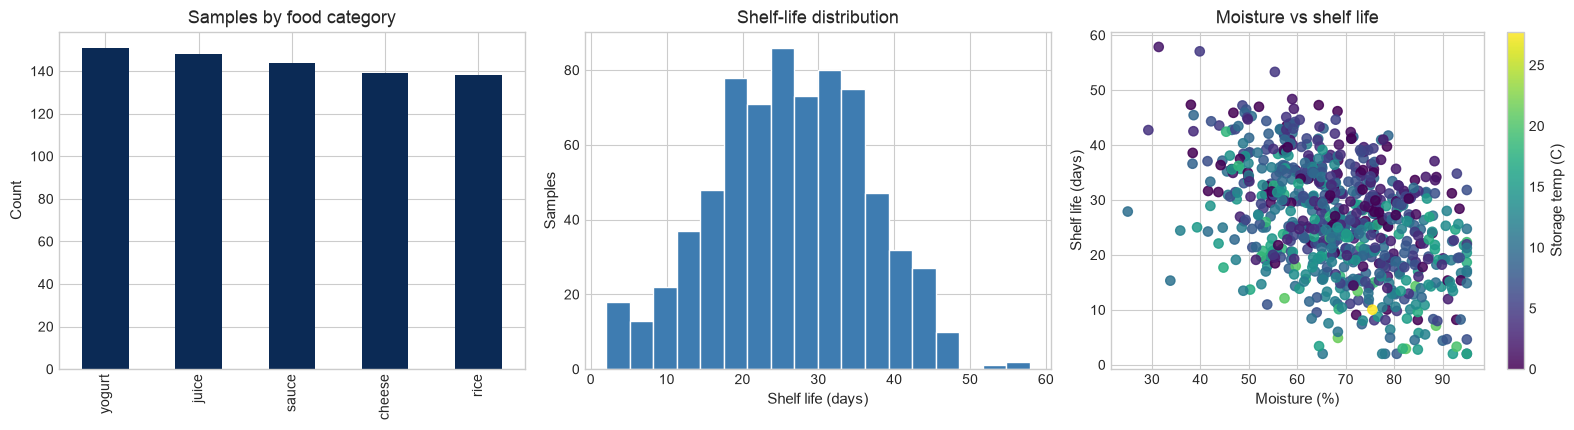

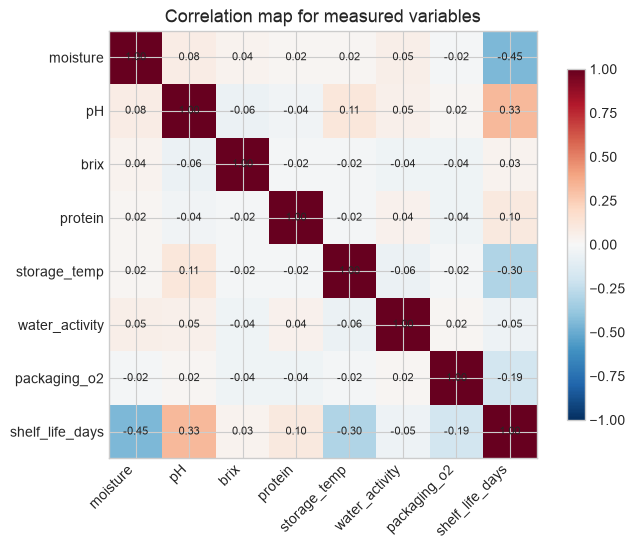

In [3]:
numeric_cols = ['moisture', 'pH', 'brix', 'protein', 'storage_temp', 'water_activity', 'packaging_o2', 'shelf_life_days']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
df['food_type'].value_counts().plot(kind='bar', ax=axes[0], color='#0B2A55')
axes[0].set_title('Samples by food category')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

axes[1].hist(df['shelf_life_days'], bins=18, color='#3E7CB1', edgecolor='white')
axes[1].set_title('Shelf-life distribution')
axes[1].set_xlabel('Shelf life (days)')
axes[1].set_ylabel('Samples')

scatter = axes[2].scatter(
    df['moisture'], df['shelf_life_days'],
    c=df['storage_temp'], cmap='viridis', s=45, alpha=0.85
)
axes[2].set_title('Moisture vs shelf life')
axes[2].set_xlabel('Moisture (%)')
axes[2].set_ylabel('Shelf life (days)')
fig.colorbar(scatter, ax=axes[2], label='Storage temp (C)')
plt.tight_layout()
plt.show()

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7.2, 5.6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)), corr.columns)
ax.set_title('Correlation map for measured variables')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout()
plt.show()


In [4]:
df_model = pd.get_dummies(df, columns=['food_type'], drop_first=False)
target = 'shelf_life_days'
X = df_model.drop(columns=[target]).to_numpy(dtype='float32')
y = df_model[[target]].to_numpy(dtype='float32')

train_idx, test_idx = make_split(len(df_model))
X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train_raw, y_test_raw = y[train_idx], y[test_idx]

X_train, X_test, X_mean, X_std = standardize(X_train_raw, X_test_raw, axis=0)
y_train, y_test, y_mean, y_std = standardize(y_train_raw, y_test_raw, axis=0)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (576, 12) Test shape: (144, 12)


In [5]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.10),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=45,
    batch_size=32,
    verbose=0
)
history_table(history)


,loss,mae,val_loss,val_mae
40,0.0283,0.1299,0.0718,0.2103
41,0.0257,0.1259,0.0790,0.2181
42,0.0292,0.1348,0.0777,0.2205
43,0.0294,0.1357,0.0873,0.2232
44,0.0368,0.1516,0.0798,0.2249


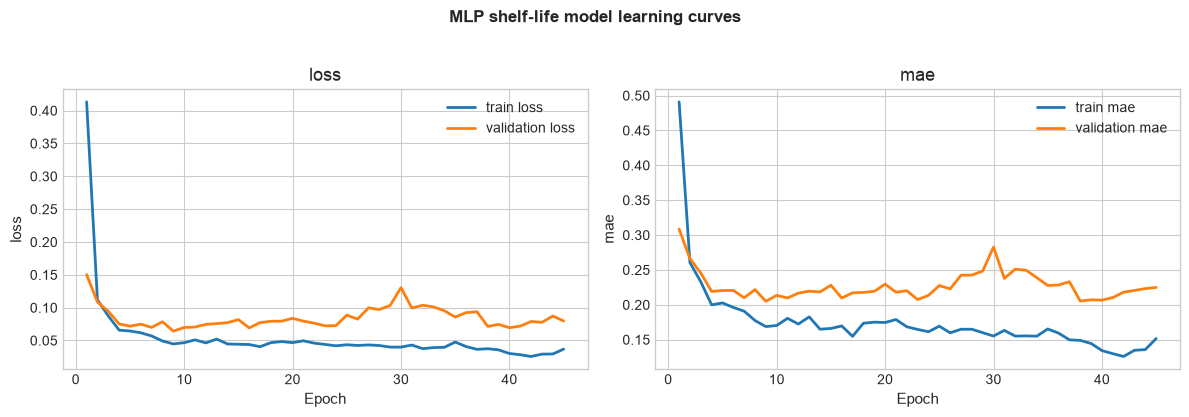

In [7]:
plot_history(history, metrics=['loss', 'mae'], title='MLP shelf-life model learning curves')


In [8]:
pred_scaled = model.predict(X_test, verbose=0)
pred_days = pred_scaled * y_std + y_mean
true_days = y_test_raw

mae = np.mean(np.abs(pred_days - true_days))
rmse = np.sqrt(np.mean((pred_days - true_days) ** 2))
print(f'Test MAE: {mae:.2f} days')
print(f'Test RMSE: {rmse:.2f} days')

pd.DataFrame({
    'true_days': true_days[:12, 0],
    'predicted_days': pred_days[:12, 0],
    'absolute_error': np.abs(pred_days[:12, 0] - true_days[:12, 0])
}).round(2)


Test MAE: 2.11 days
Test RMSE: 2.64 days


,true_days,predicted_days,absolute_error
0,32.980000,32.029999,0.95
1,25.500000,25.950001,0.45
2,47.209999,42.970001,4.24
3,46.470001,39.470001,7.00
4,36.360001,36.709999,0.35
5,19.059999,15.330000,3.73
6,34.189999,31.670000,2.52
7,36.430000,31.690001,4.74
8,31.219999,26.730000,4.49
9,44.209999,41.330002,2.88


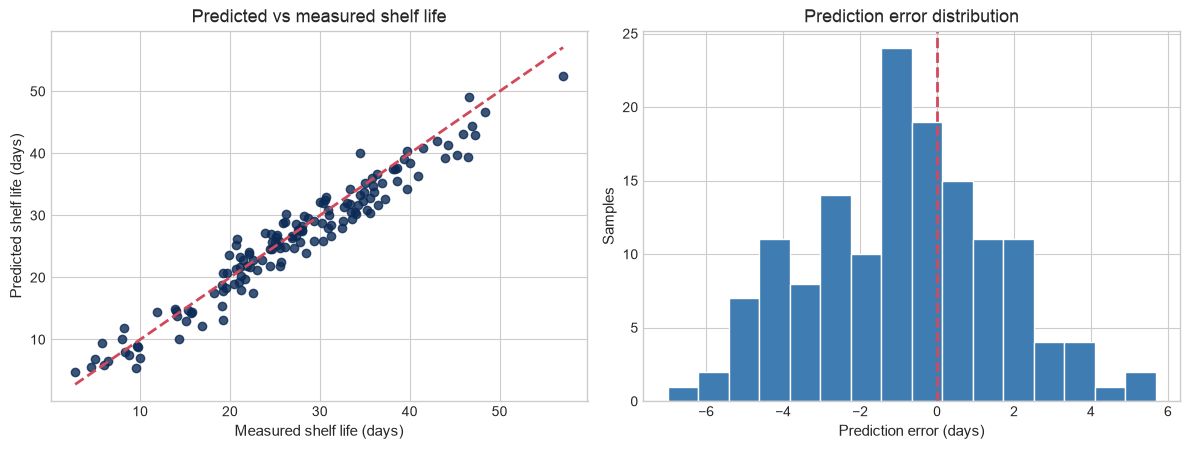

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(true_days.ravel(), pred_days.ravel(), color='#0B2A55', alpha=0.8)
lo = min(true_days.min(), pred_days.min())
hi = max(true_days.max(), pred_days.max())
axes[0].plot([lo, hi], [lo, hi], '--', color='#D1495B', linewidth=2)
axes[0].set_title('Predicted vs measured shelf life')
axes[0].set_xlabel('Measured shelf life (days)')
axes[0].set_ylabel('Predicted shelf life (days)')

errors = (pred_days - true_days).ravel()
axes[1].hist(errors, bins=16, color='#3E7CB1', edgecolor='white')
axes[1].axvline(0, color='#D1495B', linestyle='--', linewidth=2)
axes[1].set_title('Prediction error distribution')
axes[1].set_xlabel('Prediction error (days)')
axes[1].set_ylabel('Samples')
plt.tight_layout()
plt.show()


## Teaching notes
- Keep a tree-based or linear baseline for comparison in publications.
- Split by batch, supplier, production date, or season when possible.
- Report MAE/RMSE in original units, not only scaled loss.